# LOBSTER TimeGAN: return distributions

Compare the saved TimeGAN predictions with the **training split** (the first
85% of AMZN events). Run this notebook from top to bottom. It loads
`runs/timegan/generated_features.npy` by default, or samples the checkpoint if
that file is absent. No model training is performed.

Generated features are decoded with the checkpoint's training normalization and
projected onto valid, tick-rounded order books before computing returns. These
plots therefore evaluate the final books, including the effects of projection.
The comparison uses all training events and all saved generated windows, with
probability densities so the different sample counts are comparable. Differences
are taken along event time **inside each sequence**, never between unrelated
windows. These are event-time distributions, not fixed clock-time returns.


In [1]:
from pathlib import Path
import sys

# Support launching from recognition/ or recognition/notebooks/.
project_dir = next(
    (directory for directory in (Path.cwd(), *Path.cwd().parents)
     if (directory / "dataset.py").is_file()),
    None,
)
if project_dir is None:
    raise FileNotFoundError("Launch this notebook from the recognition project.")
sys.path.insert(0, str(project_dir))

import matplotlib.pyplot as plt
import numpy as np
import torch

from dataset import LOBSTERLevel10Dataset, features_to_order_book
from predict import generate_features, load_checkpoint


In [2]:
RUN_DIR = project_dir / "runs" / "timegan"
CHECKPOINT_PATH = RUN_DIR / "model.pt"
GENERATED_FEATURES_PATH = RUN_DIR / "generated_features.npy"
USE_SAVED_PREDICTIONS = True
N_GENERATED_WINDOWS = 256  # Used only when sampling fresh predictions.
SEED = 0
MIDPOINT_BINS = 401  # Fine enough to resolve small returns near zero in this run.
GAP_BINS = 101
PSEUDOCOUNT = 0.5  # Added to every histogram bin in both distributions.


In [3]:
if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f"No saved model at {CHECKPOINT_PATH}. Set CHECKPOINT_PATH to a saved run, "
        "or train once with 'uv run python main.py'."
    )

model, checkpoint = load_checkpoint(CHECKPOINT_PATH, device="cpu")
sequence_length = checkpoint["training_config"]["sequence_length"]
train_data = LOBSTERLevel10Dataset(train=True)
feature_mean = checkpoint["feature_mean"].cpu().numpy()
feature_std = checkpoint["feature_std"].cpu().numpy()
if (checkpoint["feature_names"] != list(train_data.FEATURE_NAMES)
        or not np.allclose(feature_mean, train_data.feature_mean)
        or not np.allclose(feature_std, train_data.feature_std)):
    raise ValueError("The checkpoint's features/normalization do not match this dataset.")

if USE_SAVED_PREDICTIONS and GENERATED_FEATURES_PATH.is_file():
    generated_features = np.load(GENERATED_FEATURES_PATH, allow_pickle=False)
    prediction_source = str(GENERATED_FEATURES_PATH)
else:
    torch.manual_seed(SEED)
    torch.set_num_threads(1)
    generated_features = generate_features(
        model, N_GENERATED_WINDOWS, sequence_length,
    ).cpu().numpy()
    prediction_source = f"Fresh checkpoint samples (seed={SEED})"

expected_shape = (sequence_length, train_data.FEATURE_DIMS)
if (generated_features.ndim != 3 or len(generated_features) == 0
        or generated_features.shape[1:] != expected_shape):
    raise ValueError(f"Expected generated features shaped (windows, {expected_shape}).")
if not np.isfinite(generated_features).all():
    raise ValueError("Generated features must be finite.")

print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Predictions: {prediction_source}")
print(f"Training events: {len(train_data):,}")
print(f"Generated windows: {len(generated_features):,} × {sequence_length} events")


Checkpoint: /home/carson/projects/PatternAnalysis-2026/recognition/runs/timegan/model.pt
Predictions: /home/carson/projects/PatternAnalysis-2026/recognition/runs/timegan/generated_features.npy
Training events: 229,286
Generated windows: 256 × 64 events


In [4]:
# Decoding is row-wise; reshaping back preserves independent sequence boundaries.
generated_books = features_to_order_book(
    generated_features.reshape(-1, train_data.FEATURE_DIMS),
    feature_mean, feature_std,
).to_numpy().reshape(generated_features.shape)
training_books = train_data.books.to_numpy()[None, ...]


def book_prices(books):
    """Return integer LOBSTER prices, shaped (sequence, event, level)."""
    return books[..., 0::4], books[..., 2::4]


training_asks, training_bids = book_prices(training_books)
generated_asks, generated_bids = book_prices(generated_books)


## Midpoint log returns and KL divergence

The midpoint is $m_t = (a_{1,t} + b_{1,t})/2$ and its log return is
$r_t = \log(m_t) - \log(m_{t-1})$.

Both distributions use the **same equal-width histogram bins covering their full
combined range**. Add `PSEUDOCOUNT = 0.5` observations to each bin, then normalize
counts into probabilities. The plotted densities are these smoothed probabilities
divided by bin width; the KL calculation uses exactly the same probabilities:

$$D_{\mathrm{KL}}(P_{\mathrm{training}}\Vert P_{\mathrm{TimeGAN}})
= \sum_i P_i\log(P_i/Q_i).$$

Natural logarithms give divergence in **nats**. Smoothing prevents empty generated
bins from giving infinite divergence. This is a histogram estimate: its value
depends on bin count, smoothing, and generated sample count. The second panel
zooms into the training distribution's central 99% of absolute returns; neither
the full plot nor the KL calculation discards tails or zero returns.


In [5]:
def histogram_distributions(training, generated, bins, pseudocount=PSEUDOCOUNT):
    """Estimate two probability distributions on common, full-support bins."""
    training = np.asarray(training, dtype=np.float64).ravel()
    generated = np.asarray(generated, dtype=np.float64).ravel()
    if training.size == 0 or generated.size == 0:
        raise ValueError("Both return samples must be nonempty.")
    if not np.isfinite(training).all() or not np.isfinite(generated).all():
        raise ValueError("Return samples must be finite.")
    if pseudocount <= 0:
        raise ValueError("Use a positive pseudocount for finite KL divergence.")

    # Symmetric bins place zero in the central bin for an odd bin count.
    limit = max(np.abs(training).max(), np.abs(generated).max())
    limit = limit if limit > 0 else 1e-6
    edges = np.linspace(-limit, limit, bins + 1)
    training_counts, _ = np.histogram(training, bins=edges)
    generated_counts, _ = np.histogram(generated, bins=edges)
    p = (training_counts + pseudocount) / (training.size + bins * pseudocount)
    q = (generated_counts + pseudocount) / (generated.size + bins * pseudocount)
    return edges, p, q


def plot_distributions(ax, edges, training_probability, generated_probability):
    widths = np.diff(edges)
    ax.stairs(training_probability / widths, edges,
              color="tab:blue", label="Training", linewidth=1.5)
    ax.stairs(generated_probability / widths, edges,
              color="tab:green", label="TimeGAN", linewidth=1.5)
    ax.set_yscale("log")
    ax.set_ylabel("Probability density (log scale)")
    ax.grid(alpha=0.2)


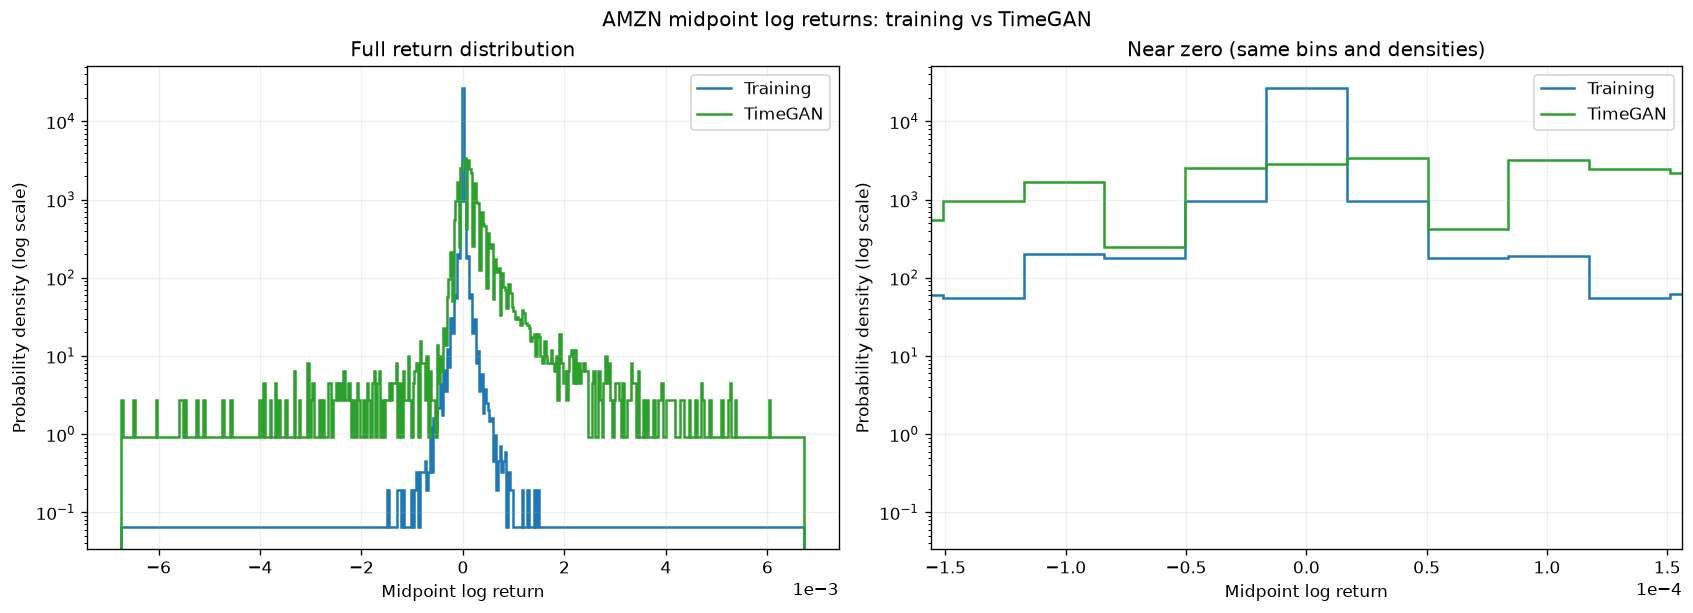

KL(training || TimeGAN) = 1.841594 nats
Common bins: 401; pseudocount per bin: 0.5
Training: 229,285 returns; zero returns = 89.59%
TimeGAN: 16,128 returns; zero returns = 9.72%


In [6]:
training_midpoints = (training_asks[..., 0] + training_bids[..., 0]) / 20_000
generated_midpoints = (generated_asks[..., 0] + generated_bids[..., 0]) / 20_000
training_midpoint_returns = np.diff(np.log(training_midpoints), axis=1).ravel()
generated_midpoint_returns = np.diff(np.log(generated_midpoints), axis=1).ravel()

midpoint_edges, midpoint_p, midpoint_q = histogram_distributions(
    training_midpoint_returns, generated_midpoint_returns, MIDPOINT_BINS,
)
midpoint_kl = np.sum(midpoint_p * np.log(midpoint_p / midpoint_q))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")
for ax in axes:
    plot_distributions(ax, midpoint_edges, midpoint_p, midpoint_q)
    ax.set_xlabel("Midpoint log return")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    ax.legend()
axes[0].set_title("Full return distribution")
zoom_limit = max(np.quantile(np.abs(training_midpoint_returns), 0.99),
                 2 * np.diff(midpoint_edges).max())
axes[1].set_xlim(-zoom_limit, zoom_limit)
axes[1].set_title("Near zero (same bins and densities)")
fig.suptitle("AMZN midpoint log returns: training vs TimeGAN")
plt.show()

print(f"KL(training || TimeGAN) = {midpoint_kl:.6f} nats")
print(f"Common bins: {MIDPOINT_BINS}; pseudocount per bin: {PSEUDOCOUNT}")
for label, returns in (("Training", training_midpoint_returns),
                       ("TimeGAN", generated_midpoint_returns)):
    print(f"{label}: {returns.size:,} returns; zero returns = {(returns == 0).mean():.2%}")


## Price gap log returns

Here **price gap returns** mean event-to-event log changes in the distance between
adjacent price levels. For levels $\ell$ and $\ell+1$, define the positive gaps
$g^{\mathrm{ask}}_{\ell,t} = a_{\ell+1,t} - a_{\ell,t}$ and
$g^{\mathrm{bid}}_{\ell,t} = b_{\ell,t} - b_{\ell+1,t}$, then calculate
$\log(g_{\ell,t}) - \log(g_{\ell,t-1})$.

Each panel compares one of the nine adjacent-level gaps on one side of the book.
It uses shared bins for training and TimeGAN, with the same smoothing as above.
All gap returns, including zeros and tails, are included. The model's `log1p`
gap features are decoded first: differencing standardized features would not
produce these log returns.


In [7]:
def gap_log_returns(asks, bids):
    """Log changes of positive adjacent-level gaps, within each sequence."""
    # Subtract integer prices to avoid floating-point noise in unchanged gaps.
    ask_gaps = np.diff(asks, axis=-1)
    bid_gaps = -np.diff(bids, axis=-1)
    if (ask_gaps <= 0).any() or (bid_gaps <= 0).any():
        raise ValueError("Log gap returns require strictly positive price gaps.")
    return {
        "Ask": np.diff(np.log(ask_gaps), axis=1),
        "Bid": np.diff(np.log(bid_gaps), axis=1),
    }


training_gap_returns = gap_log_returns(training_asks, training_bids)
generated_gap_returns = gap_log_returns(generated_asks, generated_bids)


def plot_gap_returns(side):
    fig, axes = plt.subplots(3, 3, figsize=(14, 11), layout="constrained")
    for gap_index, ax in enumerate(axes.flat):
        edges, p, q = histogram_distributions(
            training_gap_returns[side][..., gap_index],
            generated_gap_returns[side][..., gap_index],
            GAP_BINS,
        )
        plot_distributions(ax, edges, p, q)
        ax.set_title(f"Levels {gap_index + 1}–{gap_index + 2}")
        ax.set_xlabel("Price gap log return")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside upper right", ncols=2)
    fig.suptitle(f"AMZN {side.lower()} price gap log returns: training vs TimeGAN")
    plt.show()


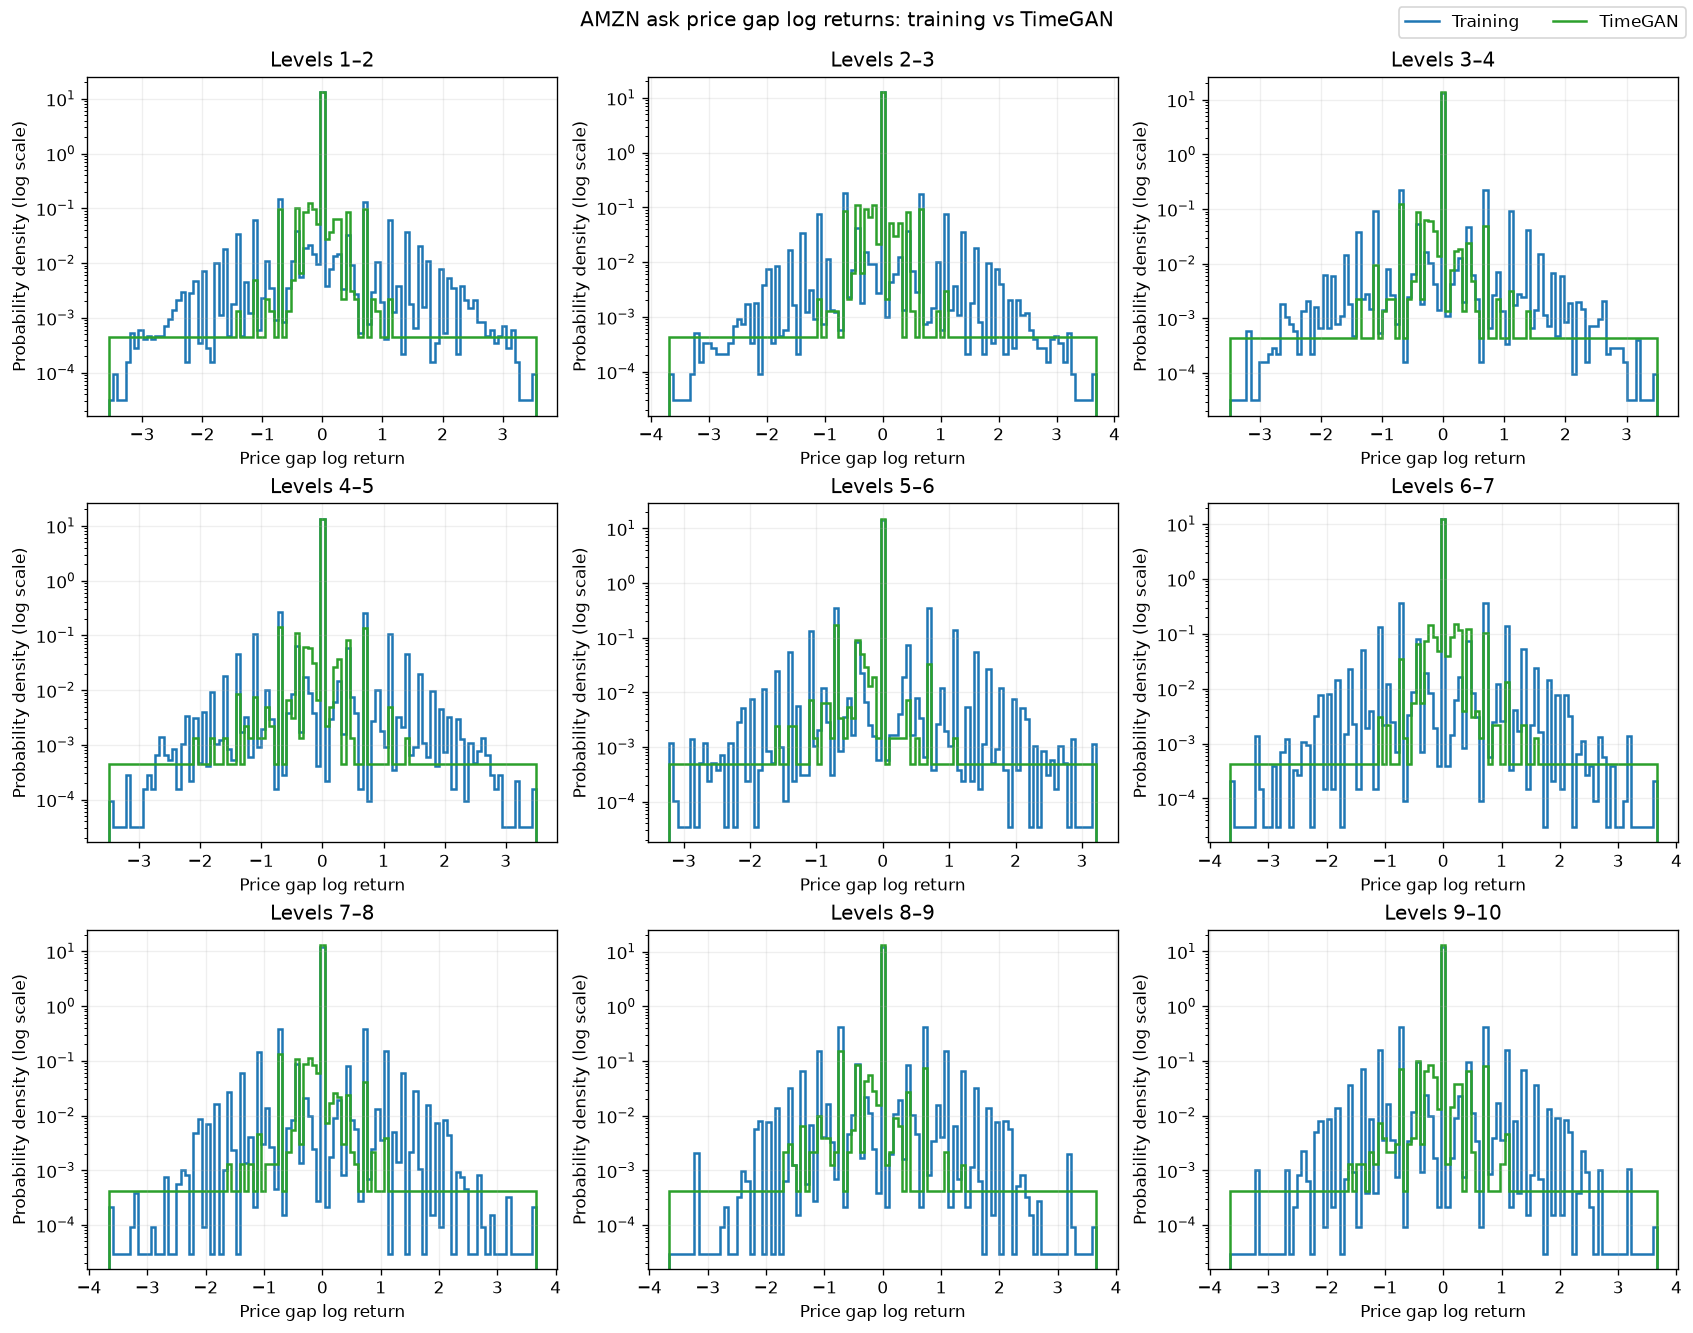

In [8]:
plot_gap_returns("Ask")


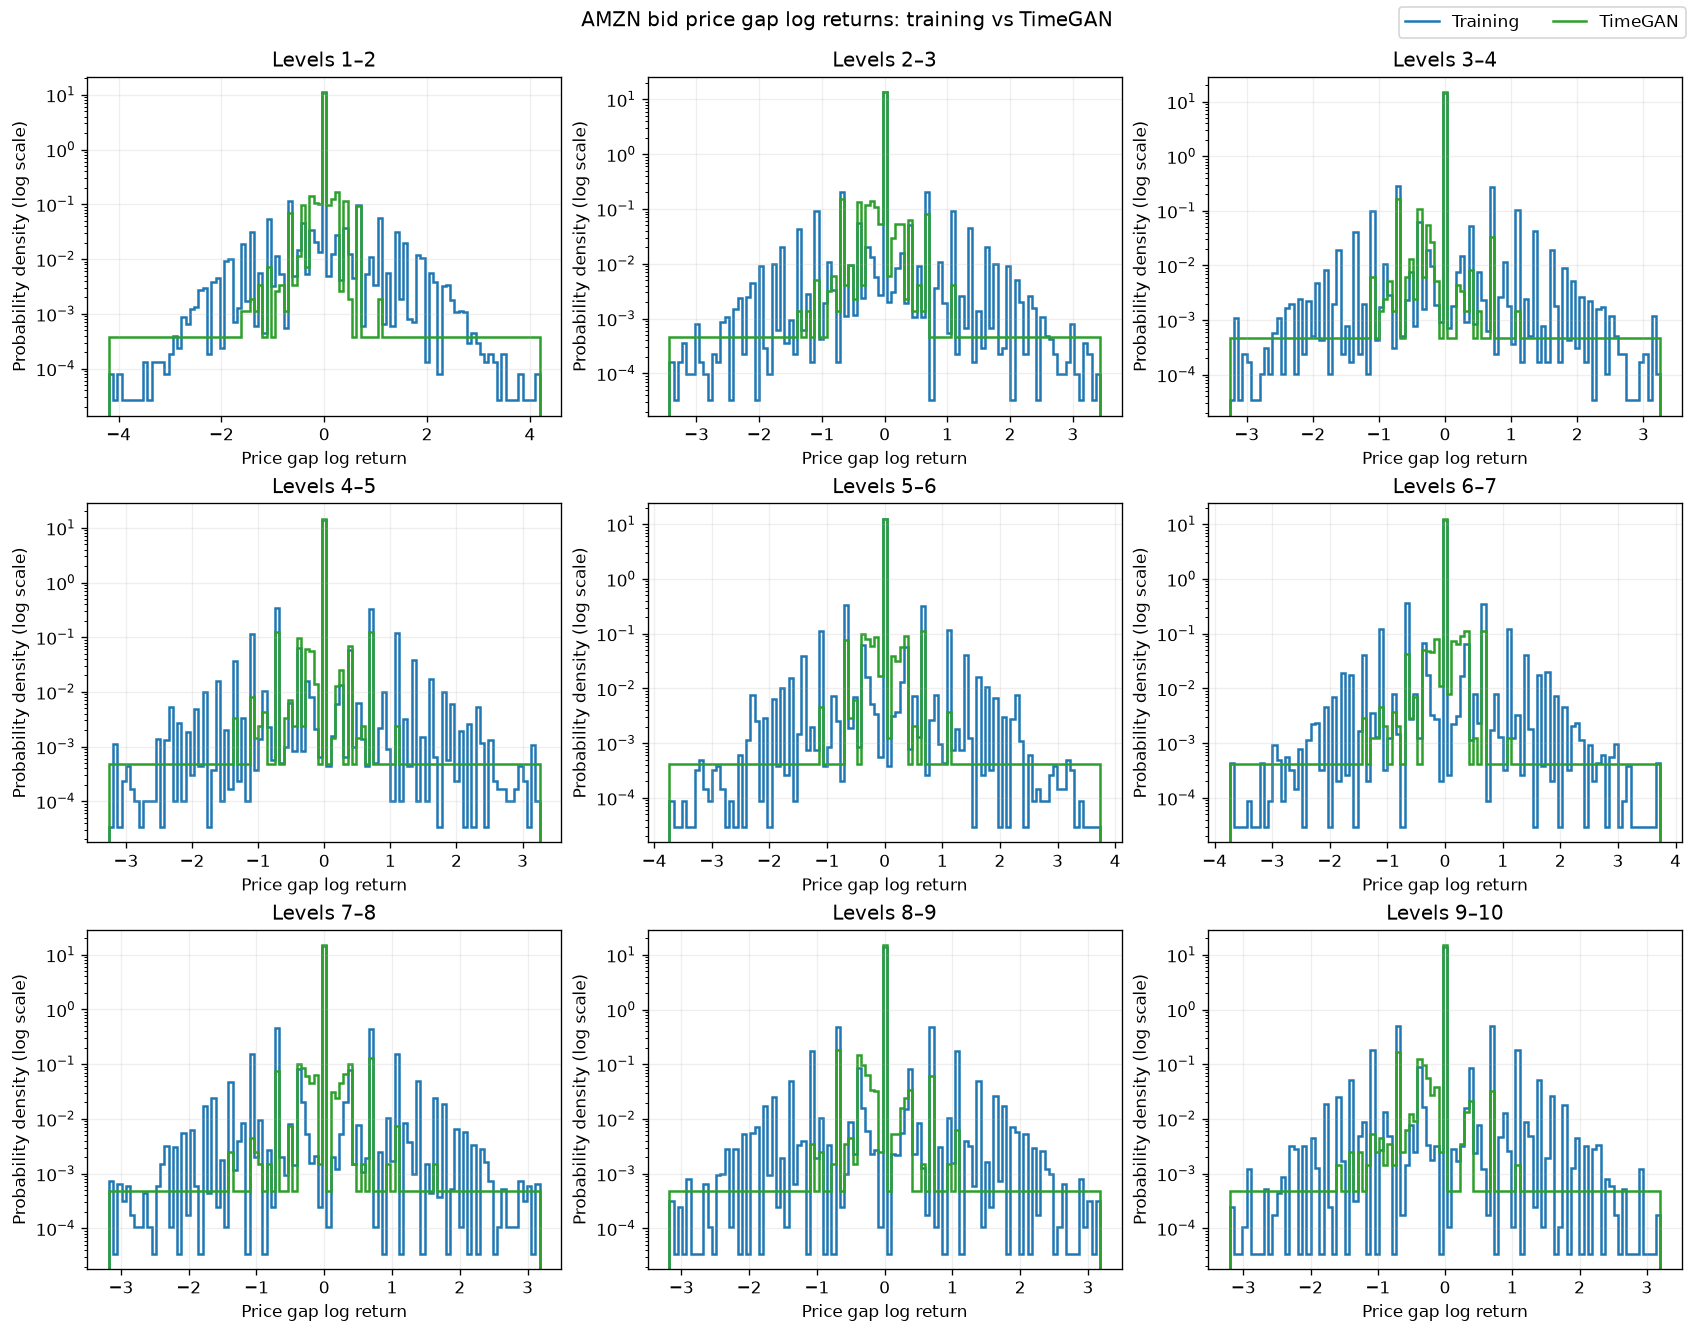

In [9]:
plot_gap_returns("Bid")
